# Validação: reflexões, cobertura e escolha do threshold

Este notebook lê a etapa parcial (baseline + autorreflexão) ou a etapa final (também reflexões do professor). Não executa modelos. O GPT-5.4 não é estudante no novo experimento.

1. Configuração e disponibilidade
2. Auditoria das falhas
3. Resultados sem corte de similaridade
4. Thresholds: acurácia, ganho nas mesmas questões e cobertura
5. Faixas disjuntas de similaridade
6. Seleção de thresholds na validação e exportações

A versão anterior foi preservada em `validation_accuracy_by_similarity_legacy.ipynb`.

In [20]:
USE_BASELINE_ON_FAILURE = False
EXPERIMENT_ID = None  # None = run de validação ativa; ou informe o ID explicitamente
PHASE = "auto"  # auto: final se disponível, senão parcial; self: parcial preservado; full: final
FINAL_RESULTS_ROOT = "results_definitivos"  # nova base consolidada (validation/test)
THRESHOLDS = [-1.0] + [i / 20 for i in range(21)]
MIN_N = 30
MIN_COVERAGE = 0.10
AUTO_YLIM = True
CLEAN_EXCLUDE_FLAGS = [
    "length_exhausted", "empty_exhausted", "context_exceeded", "content_filter",
    "partial_think", "reflection_clipped_for_context", "embedding_truncated",
]
# thinking_removed e judge_fallback não são falhas por si só.

## 1. Dados e denominadores

Com **True**, falhas e casos abaixo do threshold usam o baseline da mesma questão; se ele também falhar, contamos erro. Com **False**, esses casos saem do denominador e condições podem ter amostras diferentes. Uma resposta válida errada continua como erro.

A acurácia de cada condição é descritiva de seu conjunto. O **ganho** usa o baseline nas **mesmas questões** daquela condição, evitando comparar subconjuntos diferentes. Baselines não resolvidos nesses casos contam como erro e são explicitados em `n_baseline_unanswered`.

Os filtros adicionais só afetam a vista `filtrado`. Não criamos linhas de teacher ausente nem interpretamos a etapa ainda não rodada como falha. Similaridade igual ao threshold é aceita. Os modelos, limites, pares e prompts são os congelados no manifesto.

In [21]:
from pathlib import Path
import sys, json, hashlib
import pandas as pd
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "run_experiment.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from validation_ops import validation_id
from rmcq.test_analysis import load_run, GROUP, read_outcomes
from rmcq.validation_analysis import study, export_study, plot_study

RUN_ID = EXPERIMENT_ID or validation_id()
final_outcomes = ROOT / FINAL_RESULTS_ROOT / "validation" / RUN_ID / "analysis" / "all_outcomes.jsonl"
if final_outcomes.exists():
    rows = read_outcomes(final_outcomes, "validation")
    rows["run_id"] = RUN_ID
    sources = [str(final_outcomes.relative_to(ROOT))]
else:
    rows, sources = load_run(ROOT, RUN_ID, "validation", phase=PHASE)
if rows.empty:
    raise FileNotFoundError("Sem resultados: execute self-eval ou restaure o pacote self-eval/finish.")
manifest_path = ROOT / "experiment_exchange" / RUN_ID / "manifest.json"
manifest = json.loads(manifest_path.read_text(encoding="utf-8")) if manifest_path.exists() else {}
print("Run:", RUN_ID, "| fase:", PHASE, "| professor:", manifest.get("teacher_role", "histórico"))
print("Fontes:", sources)
print("Linhas:", len(rows), "| modelos:", rows["model"].nunique(), "| datasets:", rows["dataset"].nunique())
display(rows.groupby("model").size().rename("n_linhas").sort_values(ascending=False).to_frame())
display(rows.groupby(["dataset", "condition"]).size().rename("n_linhas").reset_index())
CONFIG = dict(run_id=RUN_ID, fallback=USE_BASELINE_ON_FAILURE, phase=PHASE,
              final_results_root=FINAL_RESULTS_ROOT,
              thresholds=THRESHOLDS, min_n=MIN_N, min_coverage=MIN_COVERAGE,
              exclude_flags=CLEAN_EXCLUDE_FLAGS, sources=sources, auto_ylim=AUTO_YLIM)
CONFIG_ID = hashlib.sha256(json.dumps(CONFIG, sort_keys=True).encode()).hexdigest()[:10]
OUT = ROOT / "data/results/reflection_top1" / RUN_ID / "analysis" / f"validation_notebook_{CONFIG_ID}"
OUT.mkdir(parents=True, exist_ok=True)
(OUT / "config.json").write_text(json.dumps(CONFIG, indent=2, ensure_ascii=False), encoding="utf-8")

def display_metrics(table):
    columns = [c for c in table if "accuracy" in c or c in ("delta_vs_baseline", "coverage", "fallback_rate")]
    display(table.style.format({c:"{:.2%}" for c in columns}, na_rep="—"))

Run: bf7731c4ac1f | fase: auto | professor: teacher-only
Fontes: ['results_definitivos/validation/bf7731c4ac1f/analysis/all_outcomes.jsonl']
Linhas: 187488 | modelos: 9 | datasets: 5


,n_linhas
model,
deepseek-r1-distill-qwen-1.5b,22461
ministral-3-8b,22461
llama3.1-8b,22461
llama3.2-3b,22461
ministral-3-3b,22461
qwen2.5-3b,22461
phi2,22461
qwen2.5-7b,22461
deepseek-r1-distill-llama-8b,7800


,dataset,condition,n_linhas
0,aqua,baseline,2268
1,aqua,self_complex,2268
2,aqua,self_simple,2268
3,arc,baseline,2682
4,arc,self_complex,2682
5,arc,self_simple,2682
6,logiqa2,baseline,13959
7,logiqa2,self_complex,13959
8,logiqa2,self_simple,13959
9,openbookqa,baseline,4491


## 2. Auditoria das falhas

As marcações se sobrepõem; suas contagens não devem ser somadas como questões distintas. `judge_fallback` é o uso do avaliador local para interpretar a resposta, não a substituição pela resposta baseline. Os limites de geração e os blocos de thinking são auditados como no teste anterior.

In [22]:
audit = rows[[*GROUP, "audit_flags"]].explode("audit_flags").dropna(subset=["audit_flags"])
audit = audit.groupby([*GROUP, "audit_flags"]).size().rename("n").reset_index()
audit.to_csv(OUT / "audit_flags.csv", index=False)
display(audit.groupby("audit_flags")["n"].sum().sort_values(ascending=False).to_frame())
display(rows.groupby(GROUP).agg(n=("failure","size"), falhas=("failure","sum"),
                               auditoria_detalhada=("audit_detail_available","mean")))
views = study(rows, fallback=USE_BASELINE_ON_FAILURE, thresholds=THRESHOLDS,
              clean_flags=CLEAN_EXCLUDE_FLAGS, min_n=MIN_N, min_coverage=MIN_COVERAGE)
export_study(views, OUT)

,n
audit_flags,
judge_fallback,62067
unresolved,18806
embedding_truncated,18696
thinking_removed,17623
length_exhausted,17540
context_exceeded,823
empty_exhausted,439
budget_reduced_for_context,31


n  falhas  \
model                        dataset    condition                    
deepseek-r1-distill-llama-8b aqua       baseline       252      96   
                                        self_complex   252     121   
                                        self_simple    252     124   
                             arc        baseline       298      14   
                                        self_complex   298      26   
...                                                    ...     ...   
qwen2.5-7b                   openbookqa self_complex   499       0   
                                        self_simple    499       0   
                             race       baseline      4887       0   
                                        self_complex  4887       0   
                                        self_simple   4887       0   

                                                      auditoria_detalhada  
model                        dataset    condition                          
deepseek-r1-distill-llama-8b aqua       baseline                      0.0  
                                        self_complex                  0.0  
                                        self_simple                   0.0  
                             arc        baseline                      0.0  
                                        self_complex                  0.0  
...                                                                   ...  
qwen2.5-7b                   openbookqa self_complex                  1.0  
                                        self_simple                   1.0  
                             race       baseline                      1.0  
                                        self_complex                  1.0  
                                        self_simple                   1.0  

[132 rows x 3 columns]

## 3. Resultados sem corte de similaridade

`n_total`: universo original; `n`: questões utilizadas; `n_reflection`: respostas com reflexão; `n_fallback`: respostas substituídas pelo baseline. `n_corrected` e `n_harmed` contam mudanças de erro para acerto e de acerto para erro, respectivamente, nas mesmas questões.

In [27]:
# for view, tables in views.items():
#     print(view)
#     display_metrics(tables["accuracy"])

## 4. Thresholds cumulativos (somente acurácia)

Cada threshold t inclui similaridades **≥ t**. Aqui mostramos apenas curvas de acurácia.

### 4.1 Completo
Inclui todos os casos da validação, sem filtros adicionais.

### 4.2 Filtrado
Exclui casos com flags em CLEAN_EXCLUDE_FLAGS.

### Diferença prática
No completo você vê o comportamento no universo total.
No filtrado você vê um recorte mais limpo, reduzindo ruídos de falhas operacionais.

=== 4.1 COMPLETO: 1 grid por modelo; subplots por dataset ===


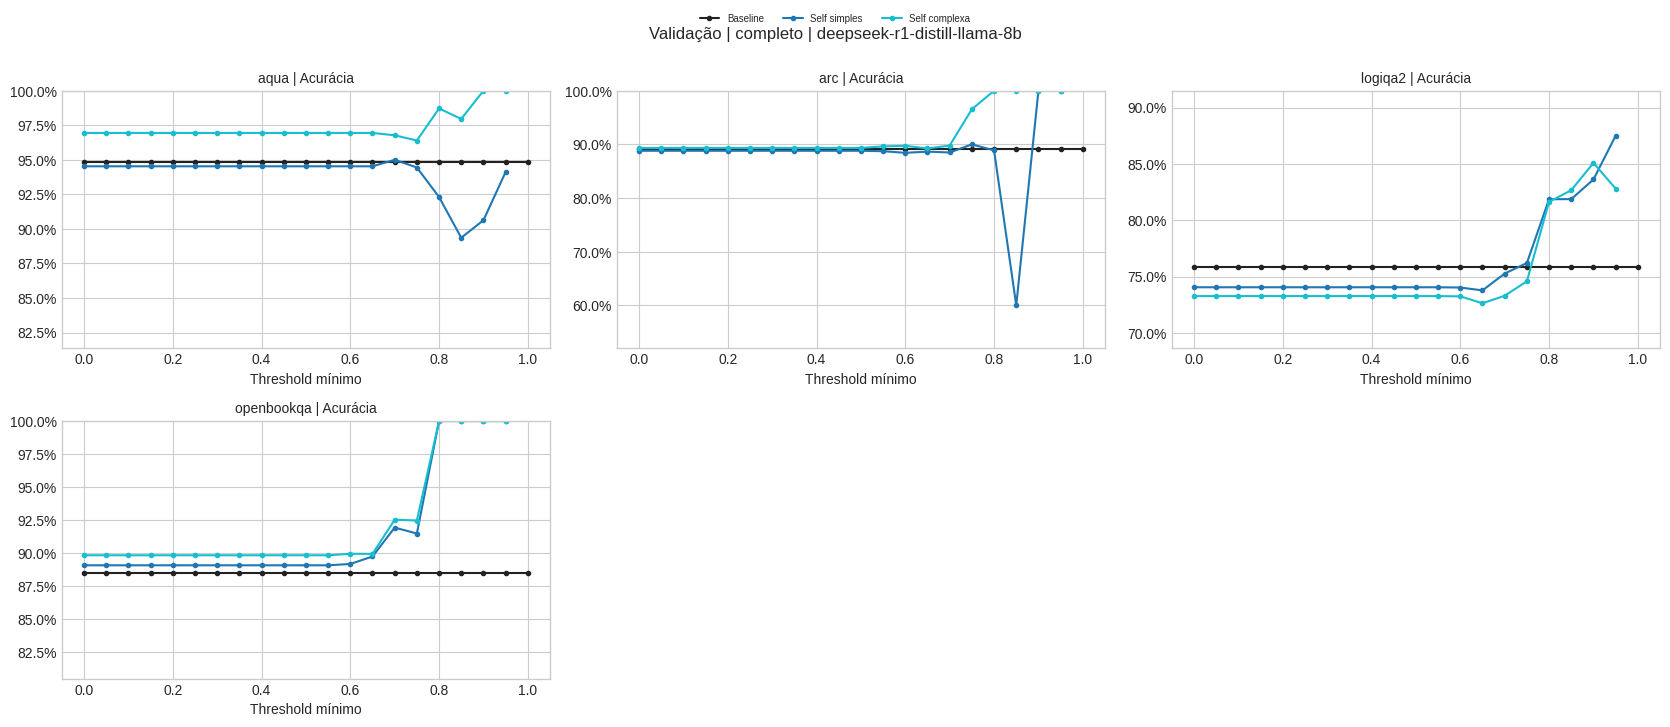

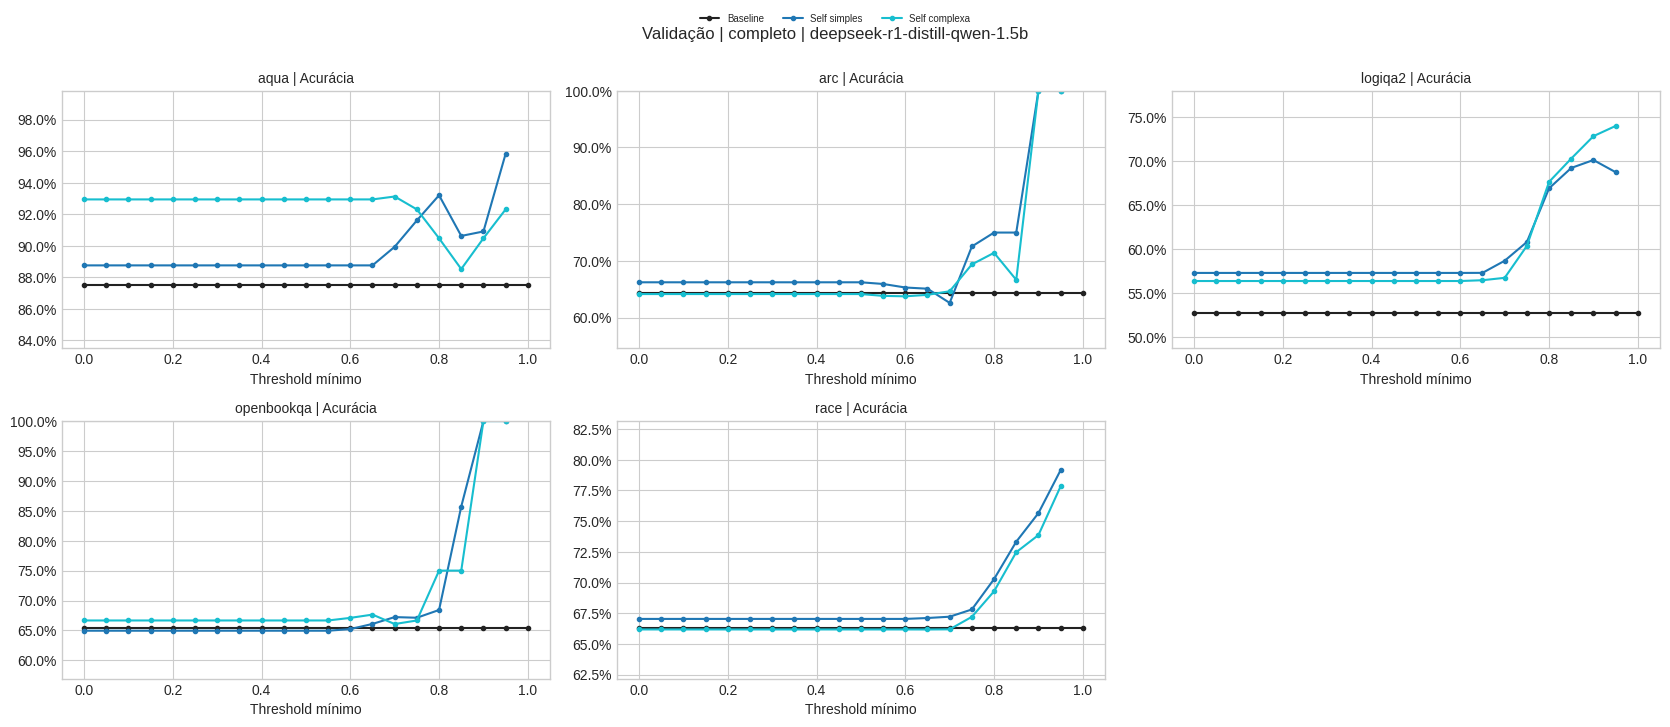

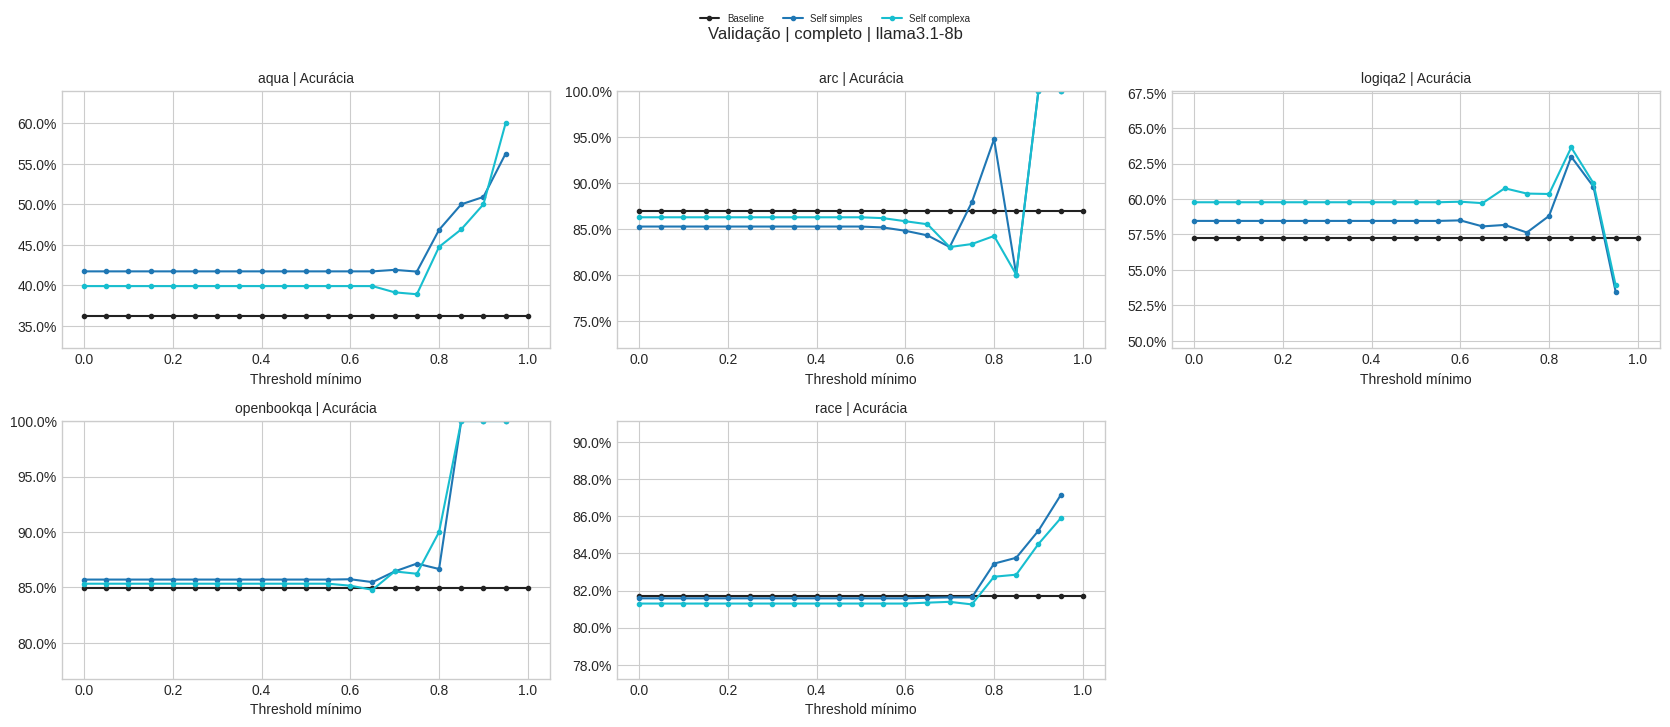

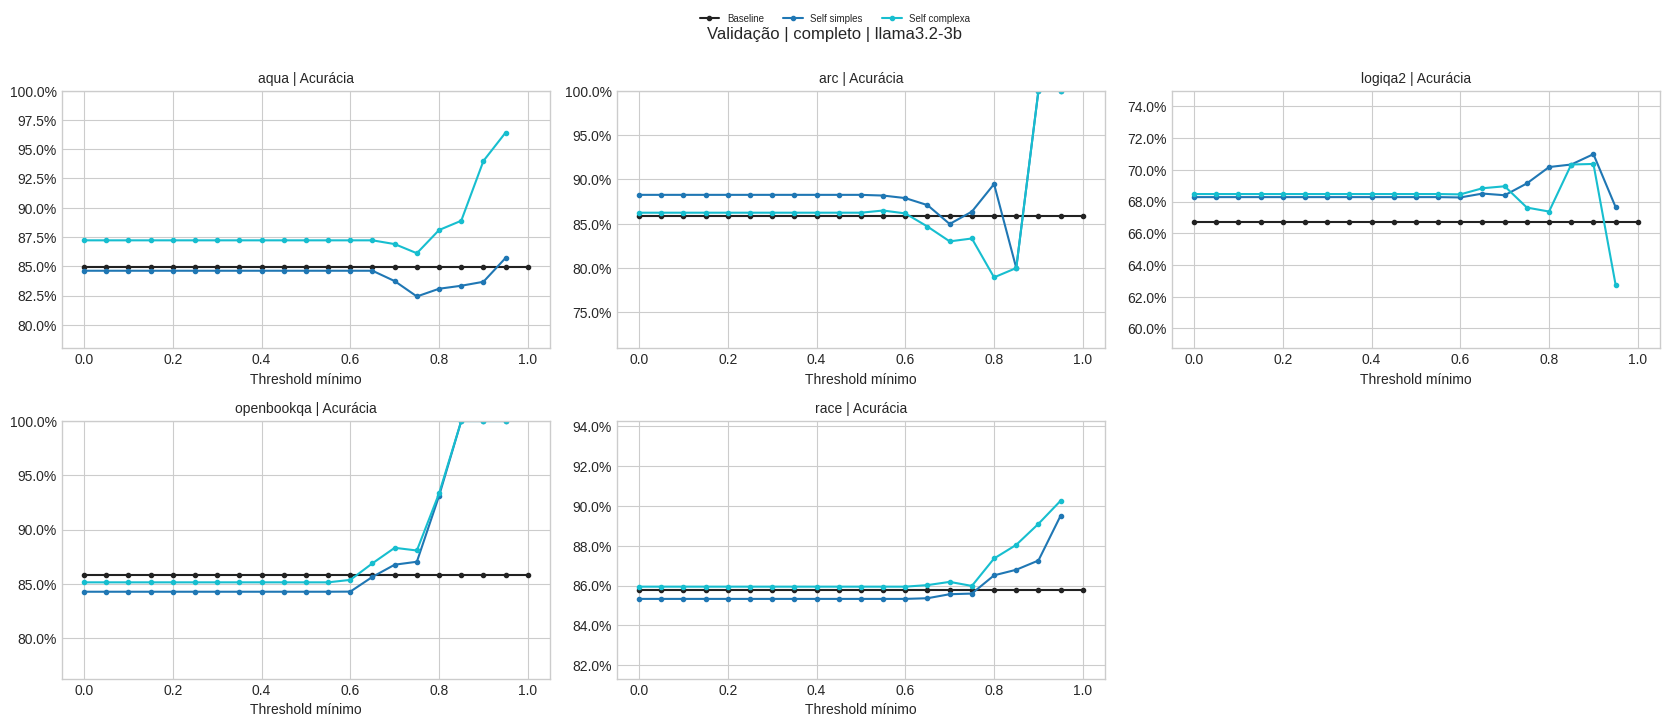

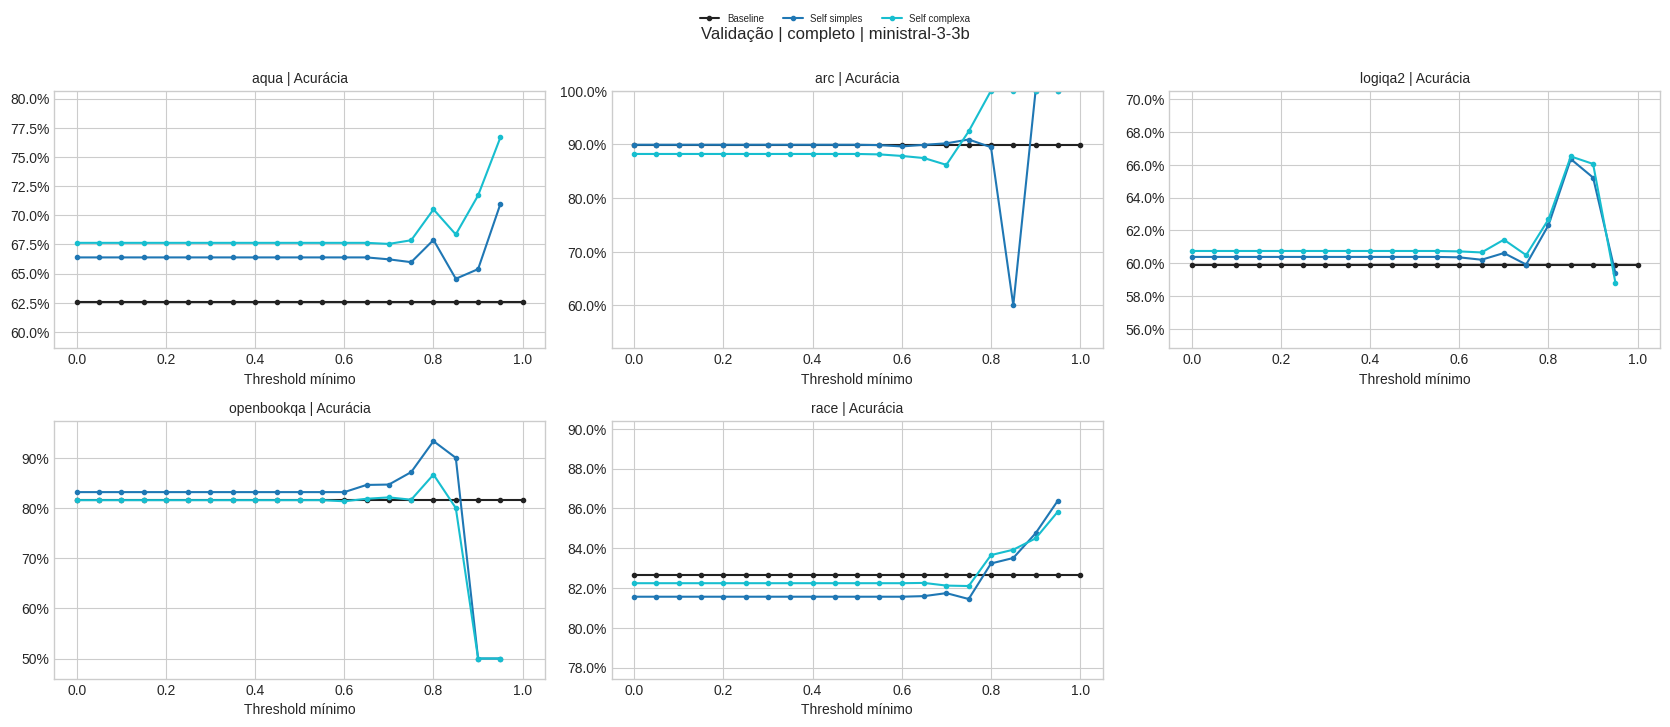

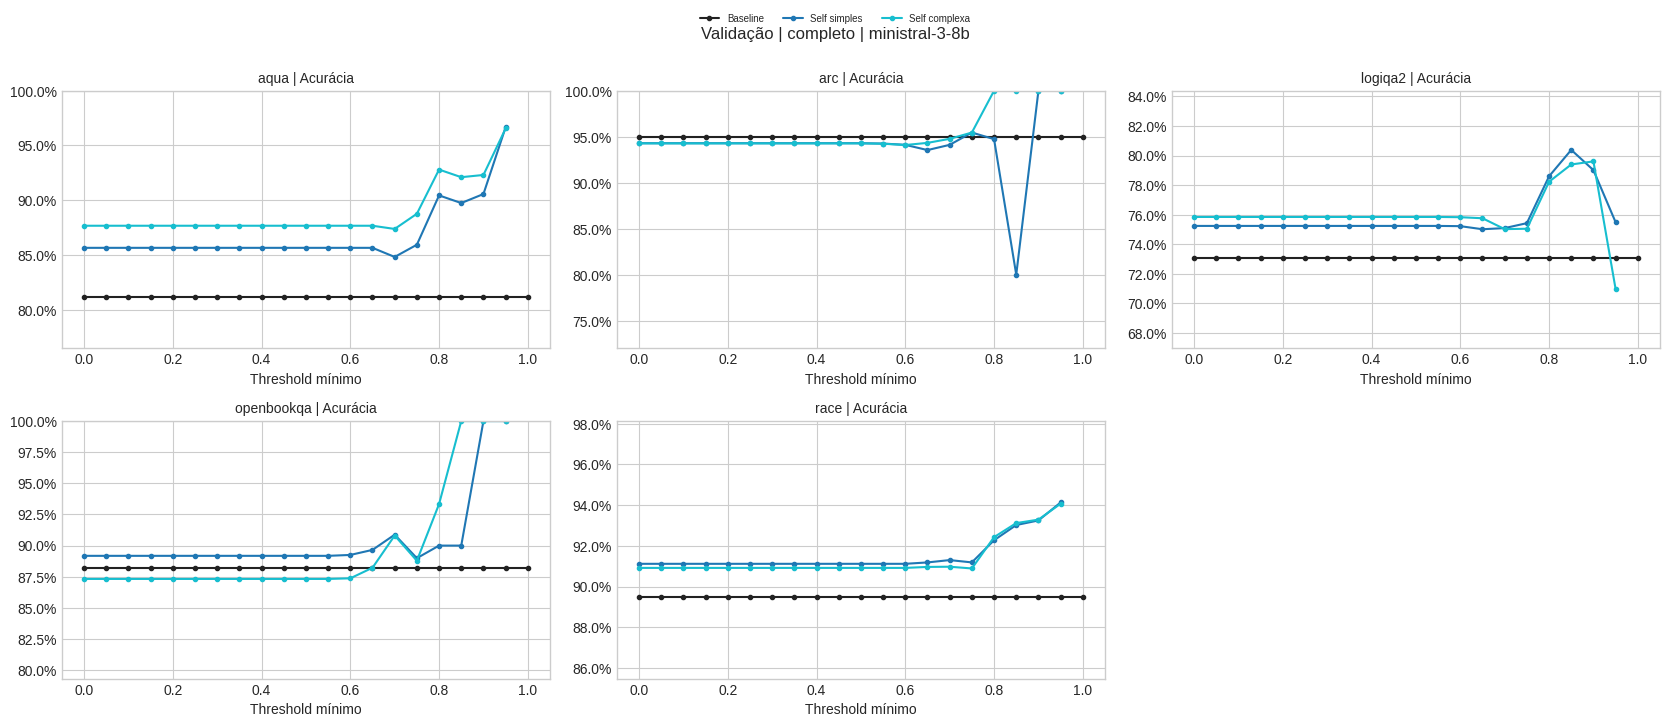

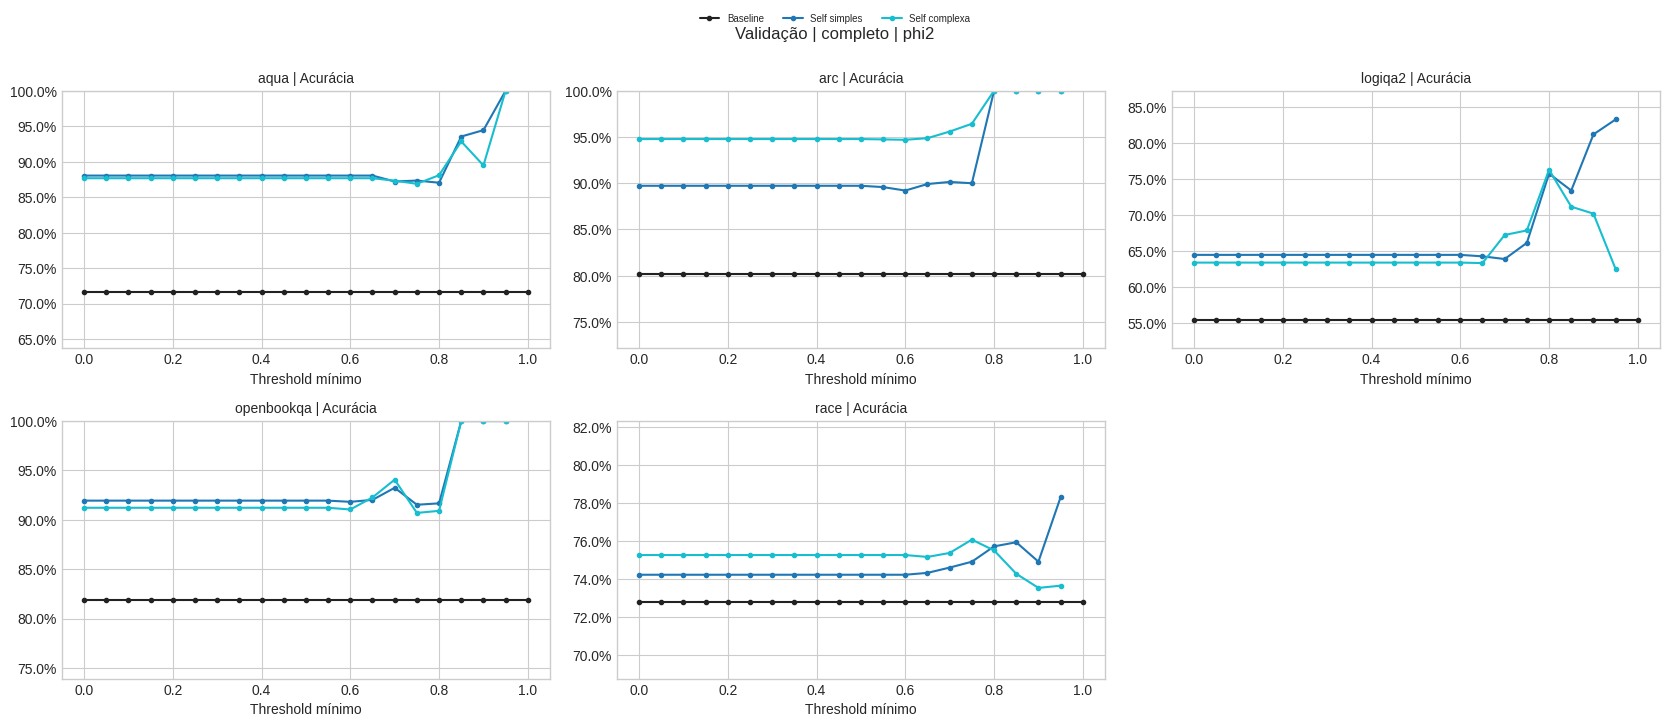

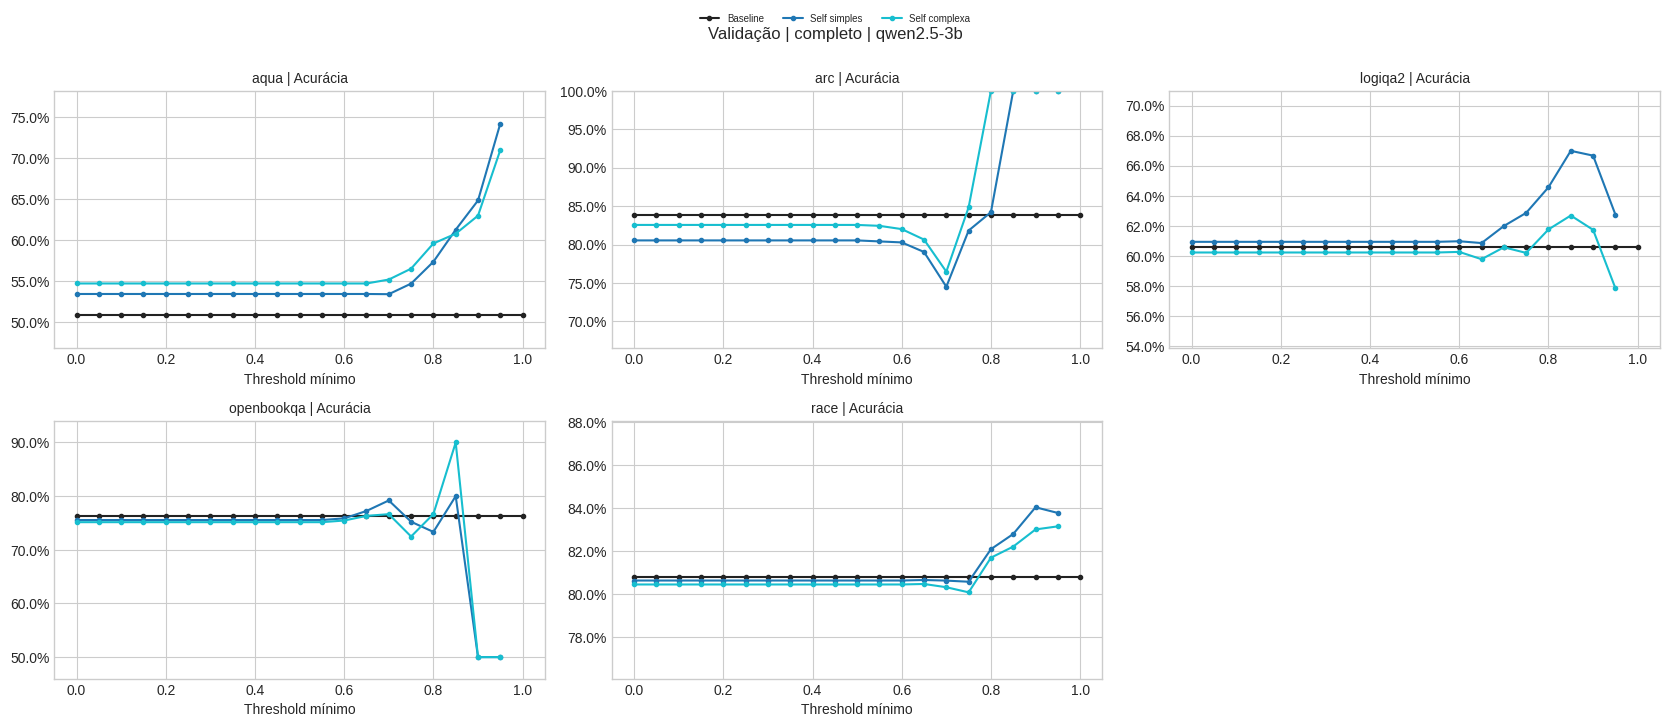

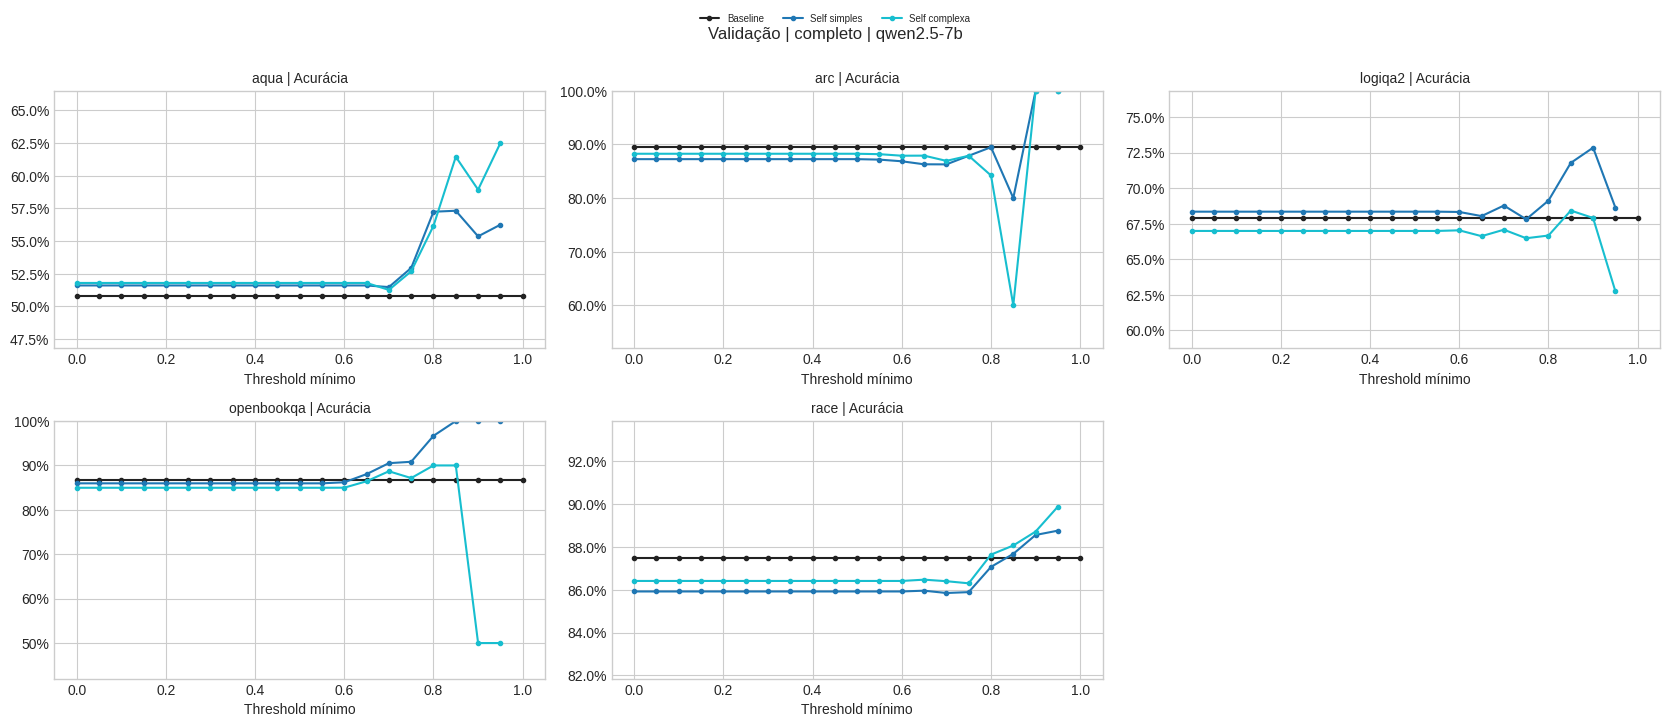

Médias macro/micro (completo):


In [31]:
print("=== 4.1 COMPLETO: 1 grid por modelo; subplots por dataset ===")
plot_study({"completo": views["completo"]}, OUT, auto_ylim=AUTO_YLIM, datasets_per_row=3)

print("Médias macro/micro (completo):")
averages = views["completo"]["averages"]
# display_metrics(averages.loc[averages.threshold.isin([-1, .7, .8, .85, .9, .95])])

# Filtrado


=== 4.2 FILTRADO: 1 grid por modelo; subplots por dataset ===


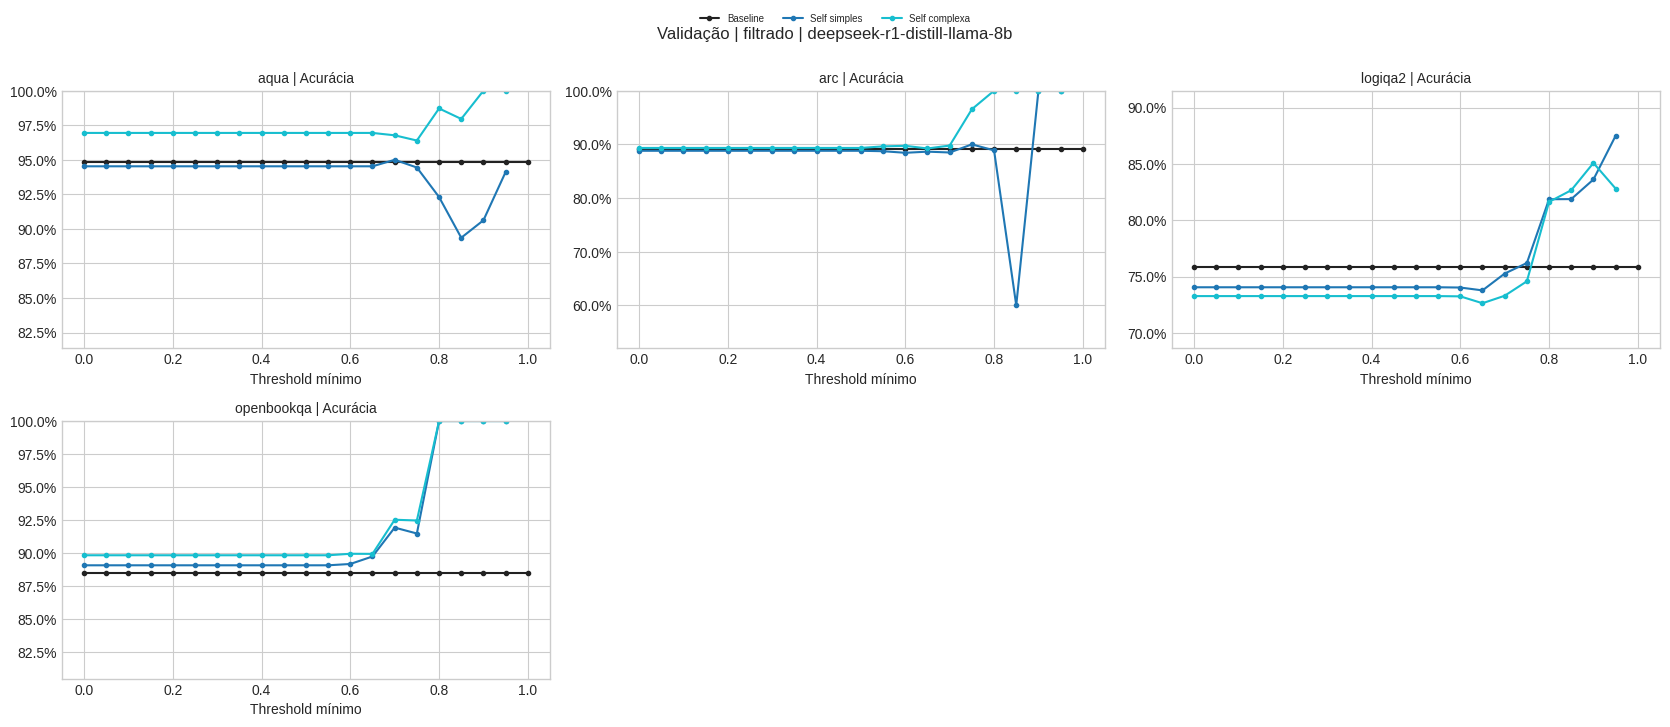

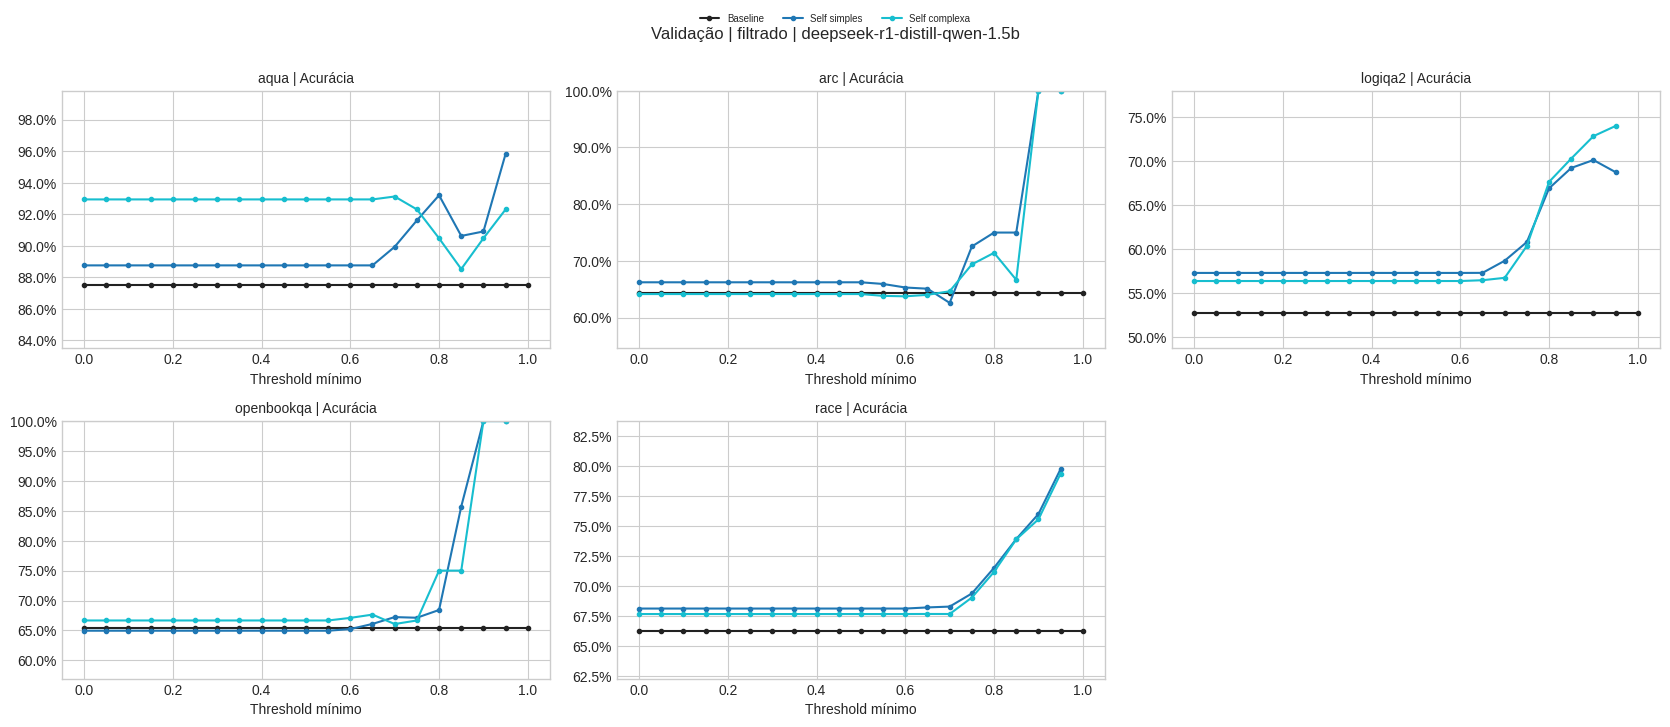

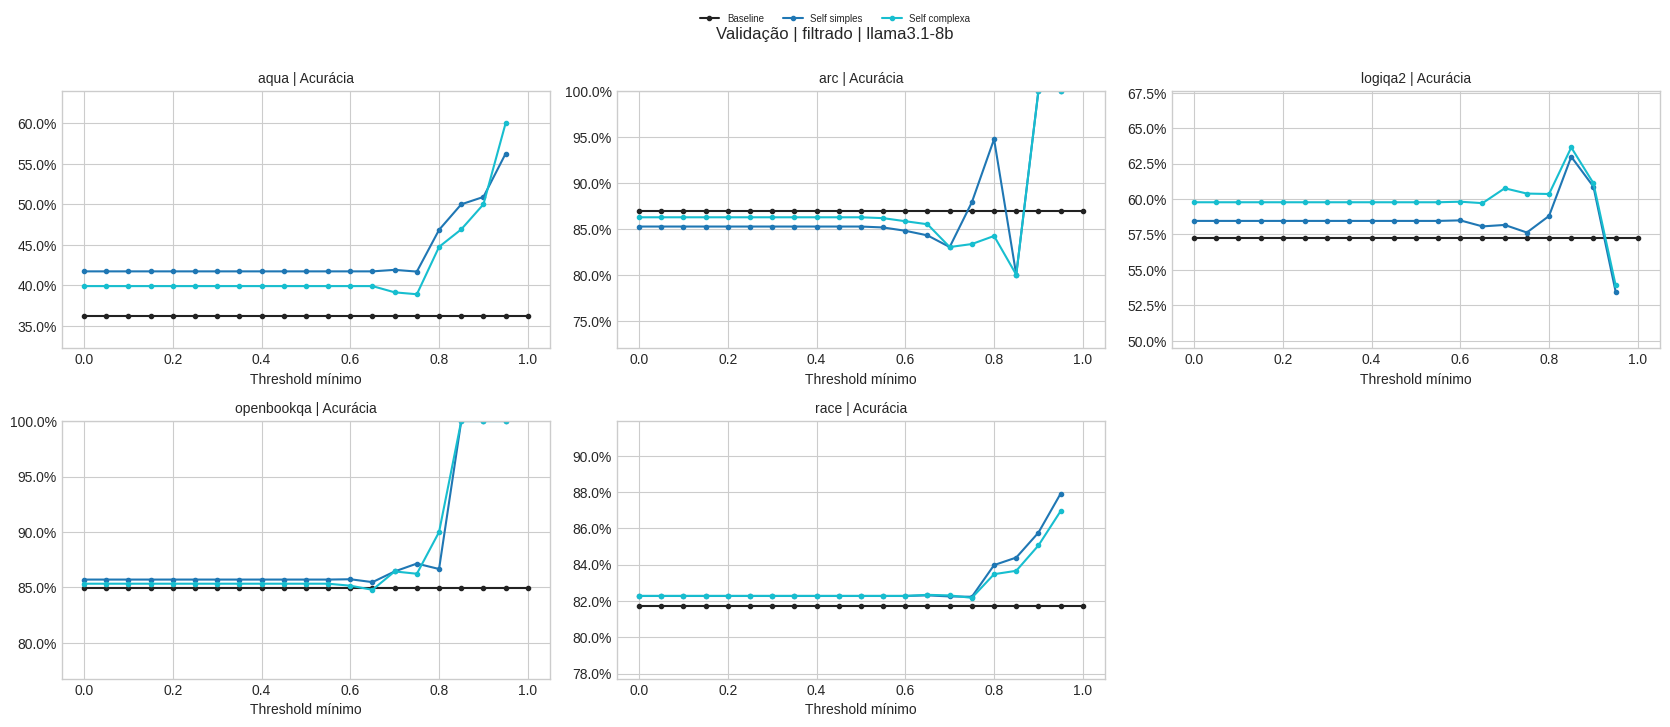

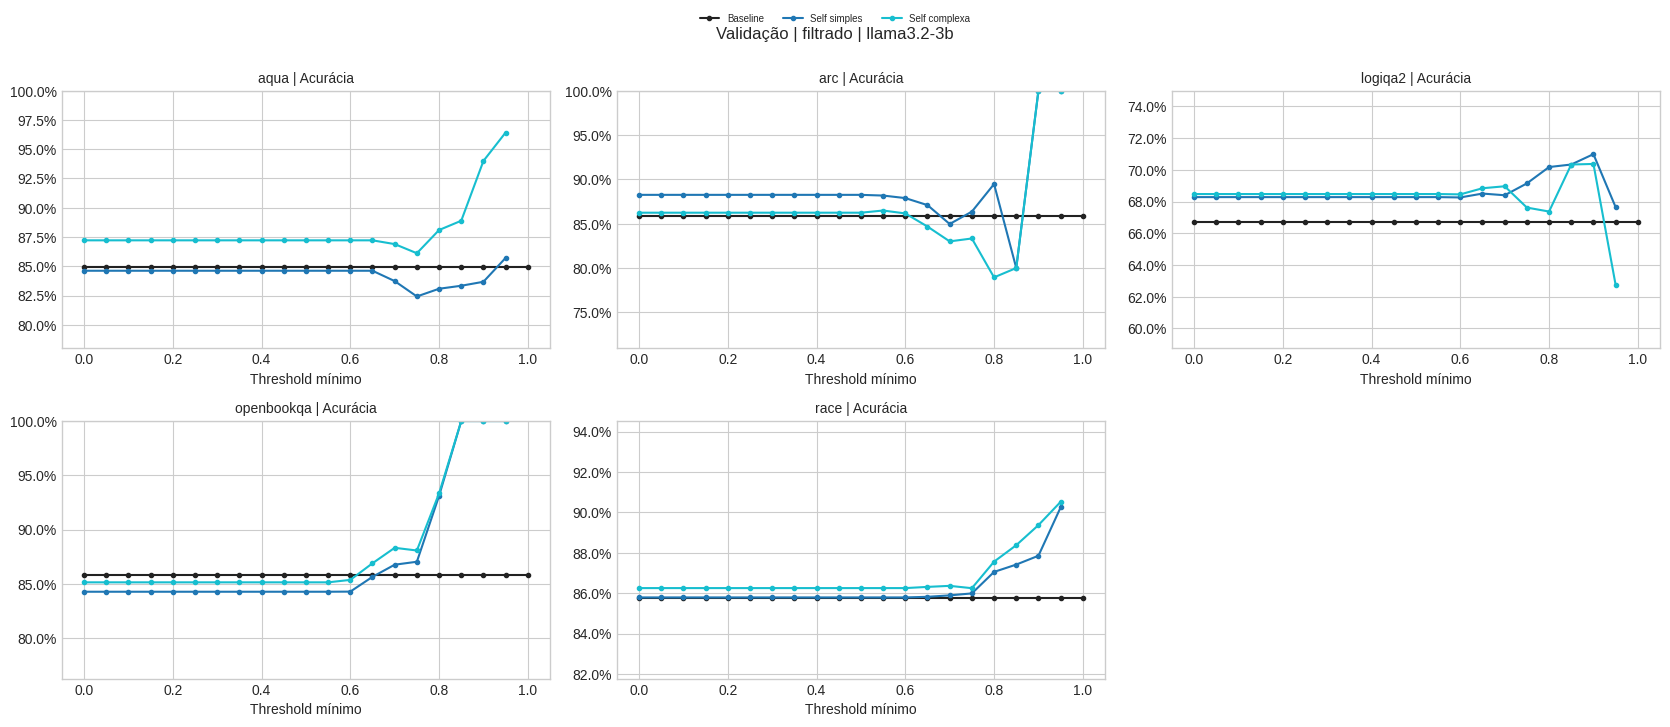

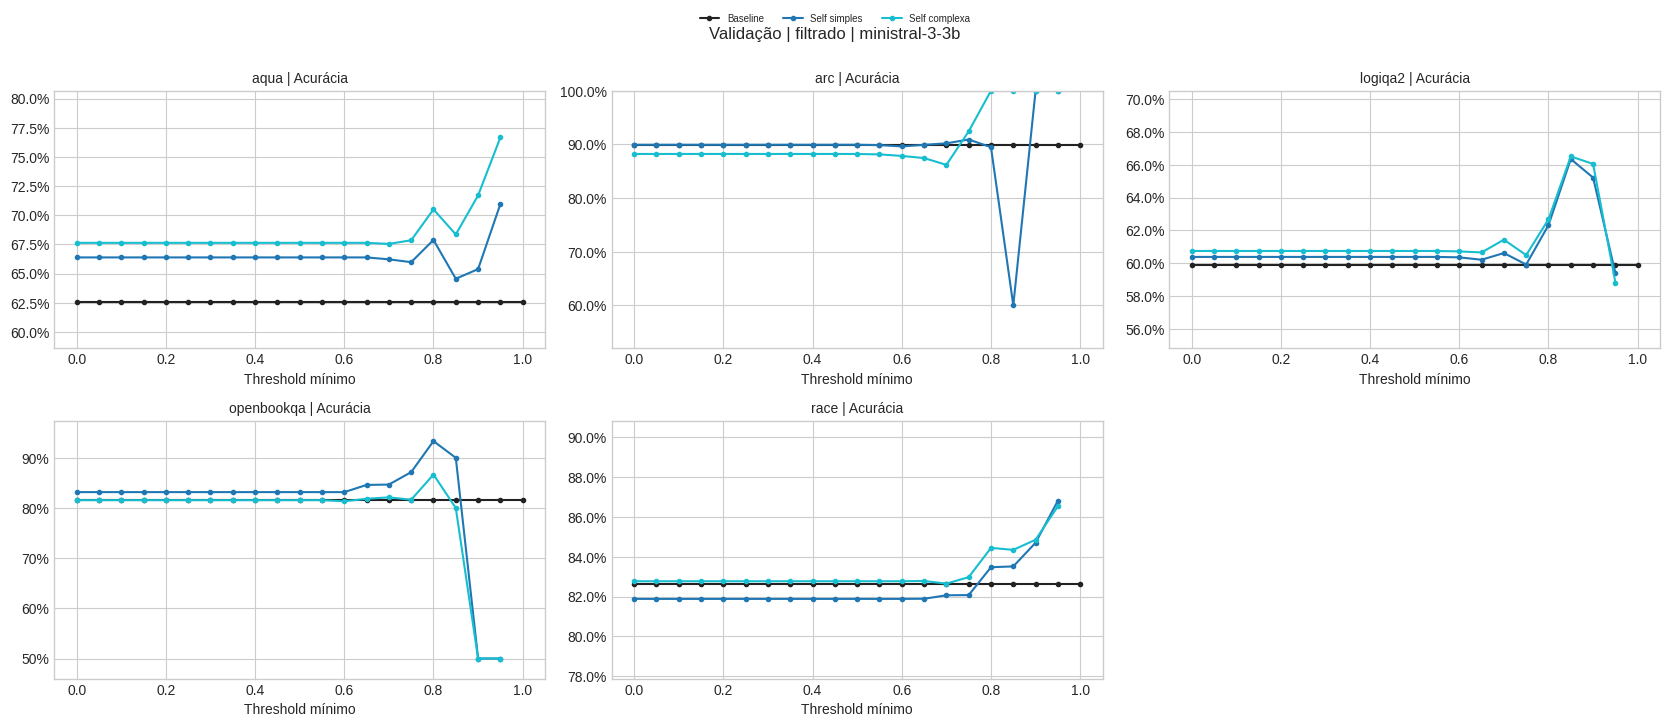

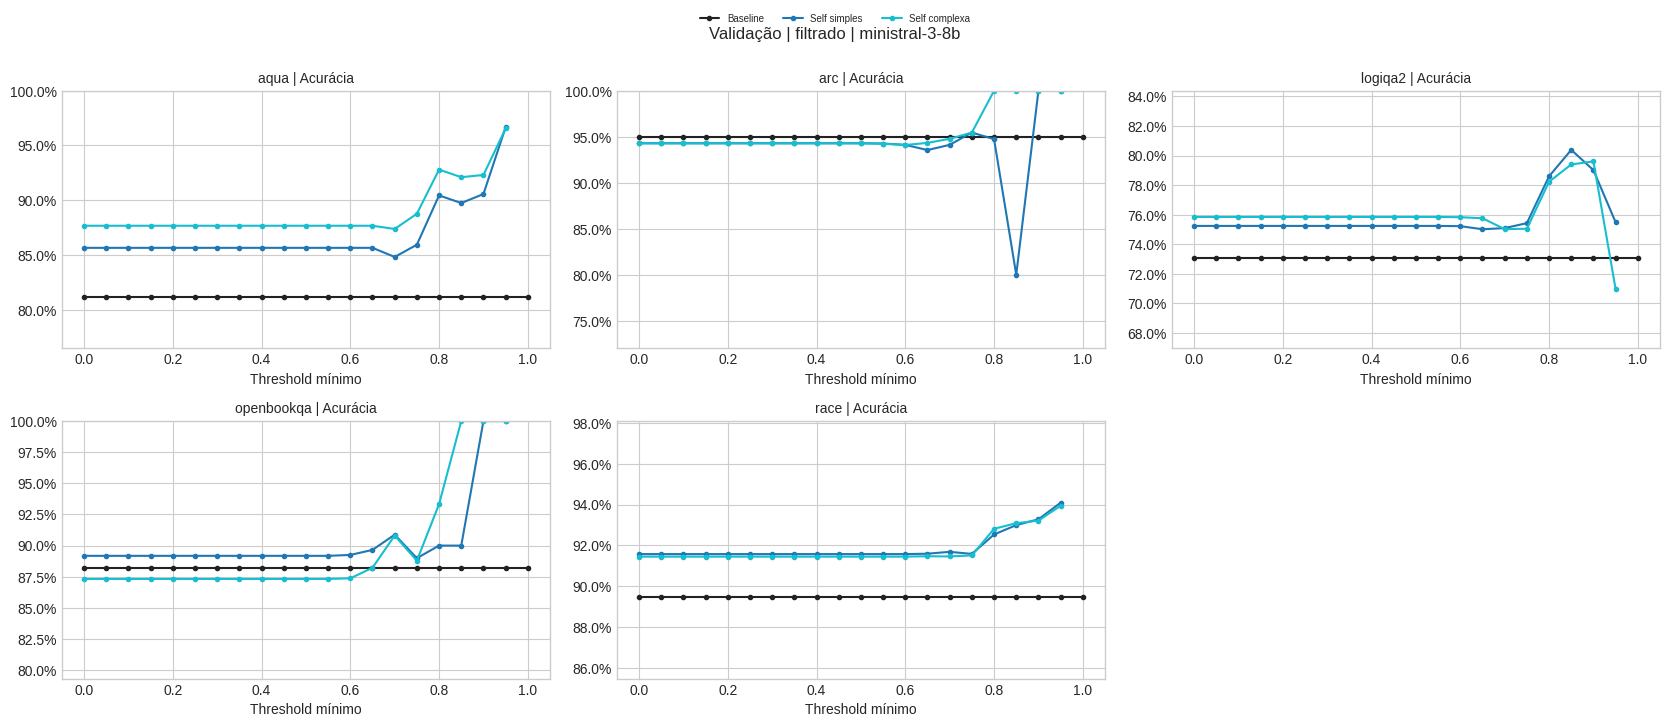

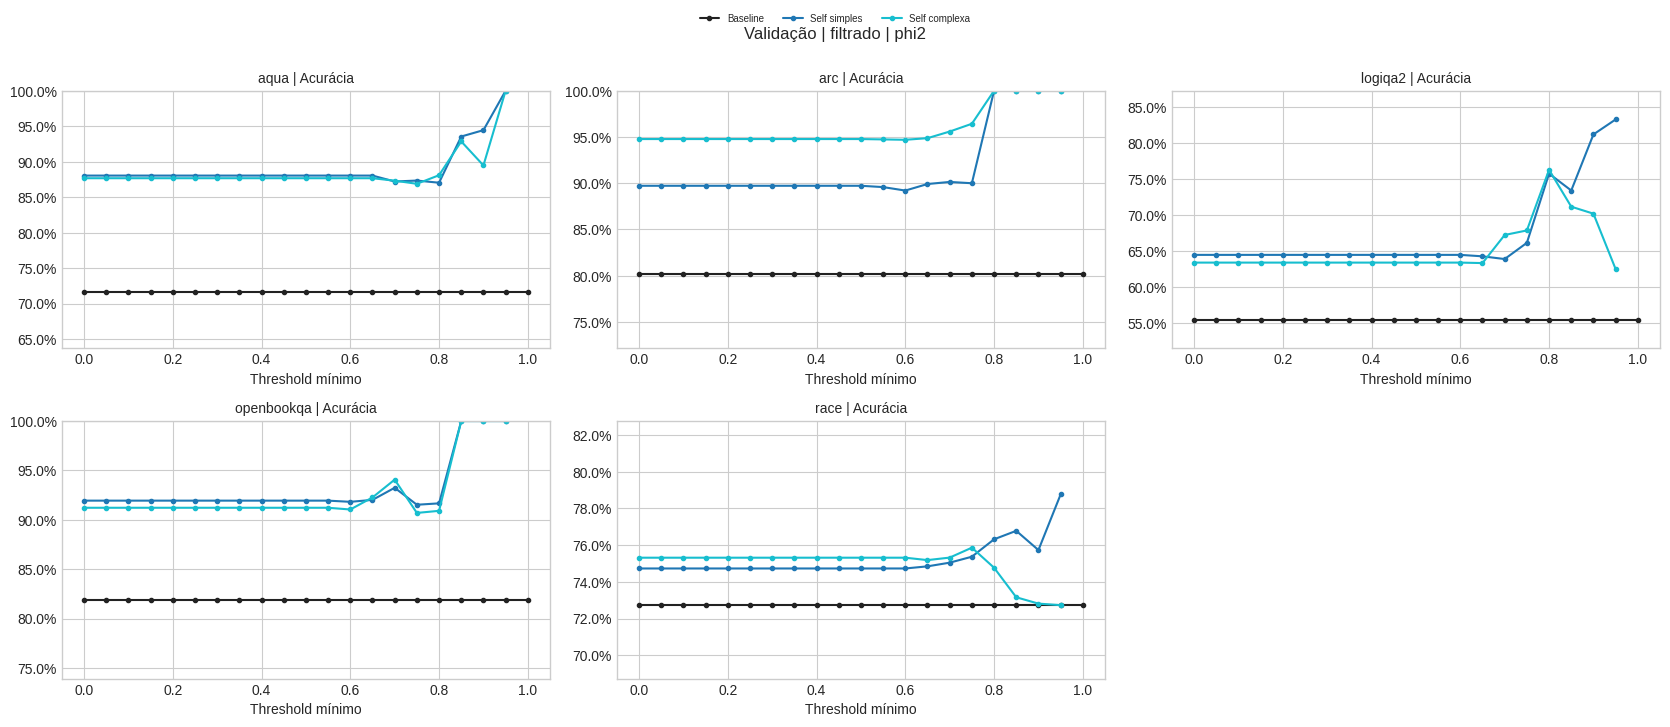

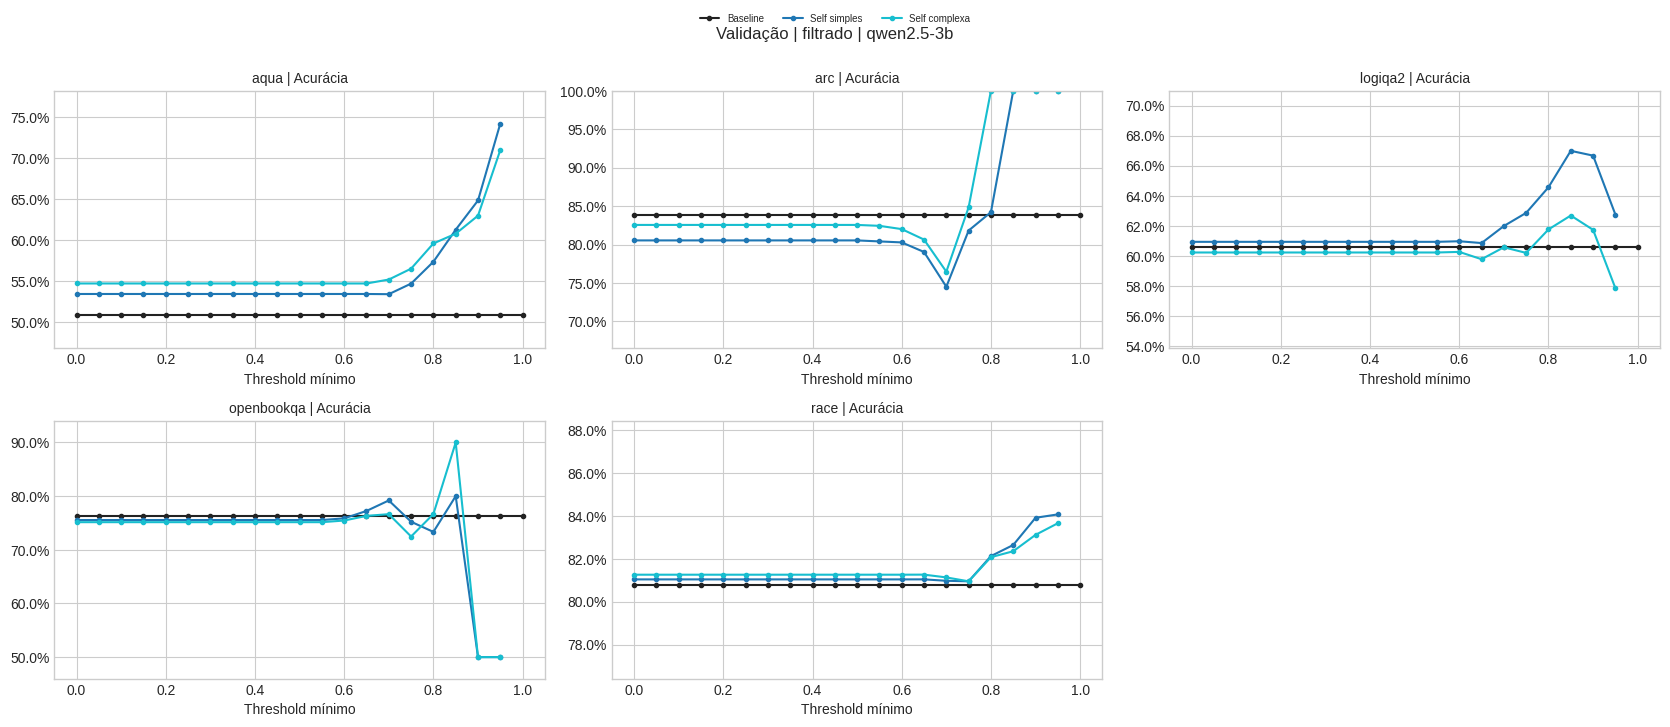

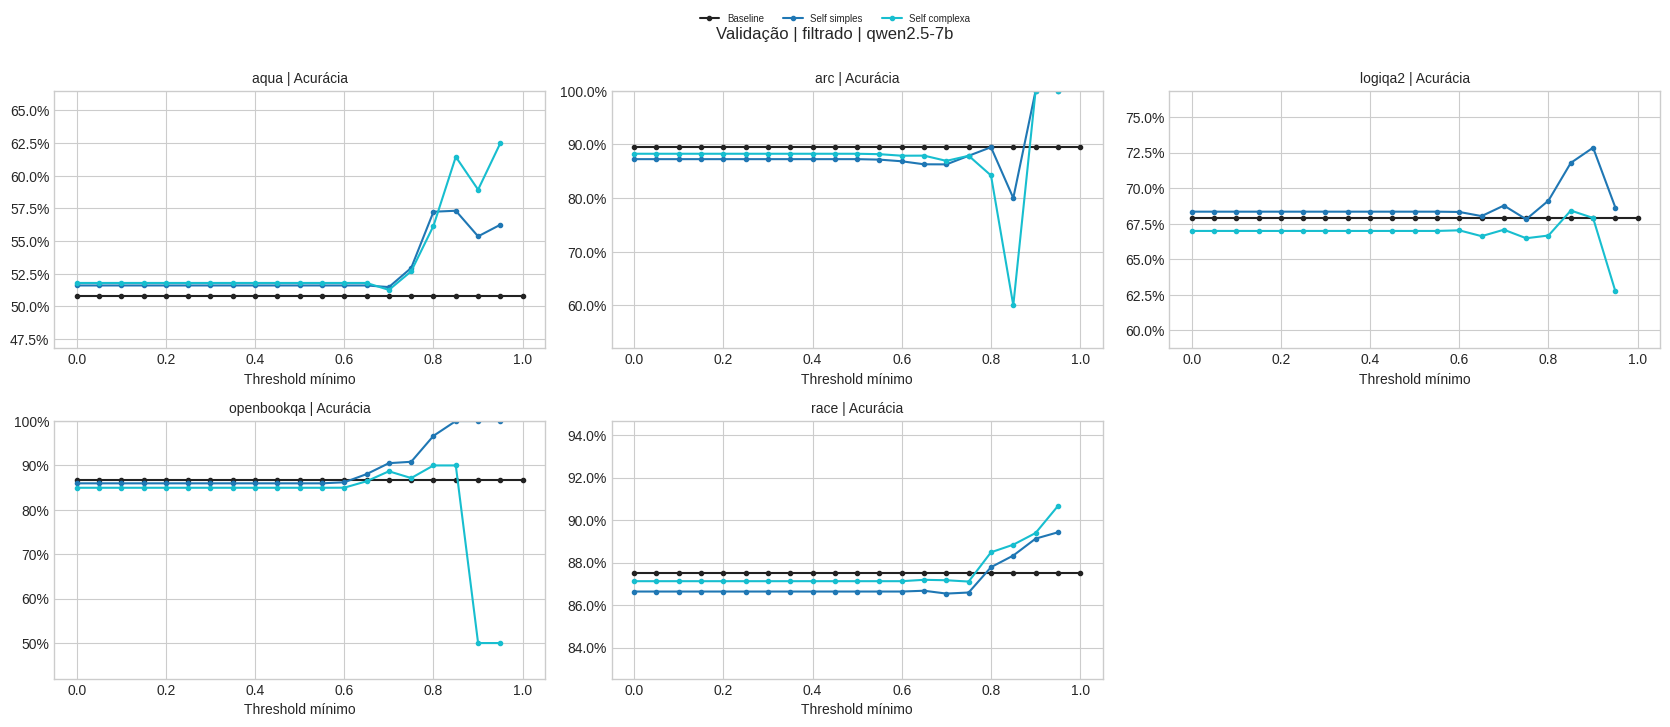

Médias macro/micro (filtrado):


In [32]:

print("\n=== 4.2 FILTRADO: 1 grid por modelo; subplots por dataset ===")
plot_study({"filtrado": views["filtrado"]}, OUT, auto_ylim=AUTO_YLIM, datasets_per_row=3)

print("Médias macro/micro (filtrado):")
averages = views["filtrado"]["averages"]
# display_metrics(averages.loc[averages.threshold.isin([-1, .7, .8, .85, .9, .95])])

## 5. Faixas disjuntas de similaridade

Estas faixas complementam os thresholds: `[0.90,0.95)` contém apenas questões nesse intervalo. Consulte `matched_baseline_accuracy` e `delta_vs_baseline`: uma acurácia menor pode coexistir com um ganho maior sobre o baseline.

In [28]:
MODEL_FILTER = None  # ex.: "ministral-3-8b"
DATASET_FILTER = None  # ex.: "logiqa2"
for view, tables in views.items():
    table = tables["bands"]
    if MODEL_FILTER:
        table = table.loc[table.model.eq(MODEL_FILTER)]
    if DATASET_FILTER:
        table = table.loc[table.dataset.eq(DATASET_FILTER)]
    # print(view)
    # display_metrics(table)

## 6. Thresholds escolhidos na validação

Seleção por modelo × dataset × condição: maior acurácia na grade, com `n >= MIN_N` e `coverage >= MIN_COVERAGE`; empates usam o menor threshold. Uma condição sem amostras elegíveis não recebe threshold. Não usamos resultados de teste nesta seleção.

Com fallback desligado, essa escolha otimiza a acurácia entre os casos aceitos e deve ser lida junto à cobertura. O valor encontrado ainda precisa ser avaliado no teste com o mesmo modelo, limites e política; não é um ótimo universal nem evidência de significância estatística. Alterar a política de fallback pode mudar a escolha.

In [29]:
for view, tables in views.items():
    print("Thresholds selecionados:", view)
    # display_metrics(tables["selected"])
print("Tabelas, configuração e figuras:", OUT)

Thresholds selecionados: completo
Thresholds selecionados: filtrado
Tabelas, configuração e figuras: /home/rodrigo.flexa/Reflection-MCQ/data/results/reflection_top1/bf7731c4ac1f/analysis/validation_notebook_de701b0b23
